# Large-Scale Demand Forecasting & Inventory Optimization (M5 Dataset)

This notebook executes the initial stages of a large-scale demand forecasting system using the **M5 Forecasting - Accuracy** dataset.

---

## STEP 1 — BUSINESS PROBLEM FORMULATION

### Problem Statement
In the competitive retail landscape, accurately predicting consumer demand is critical for maintaining high service levels while minimizing costs. This project aims to build a robust, large-scale forecasting system using the **M5 Forecasting dataset** (Walmart data) to optimize inventory across multiple stores and product categories.

*   **Forecast Objective:** Predict daily unit sales (demand) for each unique product-store pair.
*   **Forecast Horizon:** 28 days (standard retail planning window).
*   **Granularity:** SKU × Store level (Individual products across different geographical locations).
*   **Business Goal:** Inventory Optimization. By improving forecast accuracy, the system helps reduce **stockouts** (lost sales) and **overstock** (capital tied up in stagnant inventory and storage costs).
*   **Key Constraints:** 
    *   **Lead Time:** Supply chain delays require forecasts at least 28 days in advance.
    *   **Demand Uncertainty:** Intermittent demand (many zero-sales days) and volatile patterns.
    *   **Large Scale:** Managing thousands of time series simultaneously (30,490 SKU-store combinations).
*   **Target Variable:** Daily unit sales (`sales`).
*   **Real-World Use Case:** Retail supply chain management and E-commerce fulfillment, where precise replenishment is the difference between profitability and loss.

In [5]:
!pip install --upgrade --force-reinstall pandas

     ---------------------------------------- 11.4/11.4 MB 2.0 MB/s eta 0:00:00
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
     ---------------------------------------- 15.9/15.9 MB 3.3 MB/s eta 0:00:00
  Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl (348 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)
  Attempting uninstall: pytz
    Found existing installation: pytz 2022.1
    Uninstalling pytz-2022.1:
      Successfully uninstalled pytz-2022.1
  Attempting uninstall: six
    Found existing installation: six 1.16.0
    Uninstalling six-1.16.0:
      Successfully uninstalled six-1.16.0
  Attempting uninstall: numpy
    Found existing installation: numpy 1.21.5
    Uninstalling numpy-1.21.5:
      Successfully uninstalled numpy-1.21.5
  Attempting uninstall: python-dateutil
    Found existing installation: python-dateutil 2.8.2
    Uninstalling python-dateutil-2.8.2:
      Successfully u

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
daal4py 2021.6.0 requires daal==2021.4.0, which is not installed.
scipy 1.9.1 requires numpy<1.25.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.
numba 0.55.1 requires numpy<1.22,>=1.18, but you have numpy 2.0.2 which is incompatible.
conda-repo-cli 1.0.20 requires clyent==1.2.1, but you have clyent 1.2.2 which is incompatible.
conda-repo-cli 1.0.20 requires nbformat==5.4.0, but you have nbformat 5.5.0 which is incompatible.
conda-repo-cli 1.0.20 requires python-dateutil==2.8.2, but you have python-dateutil 2.9.0.post0 which is incompatible.


## STEP 2 — DATA LOADING

We load the datasets using memory-efficient techniques, as the M5 dataset can be quite large.

In [2]:
import pandas as pd
import numpy as np
import os
import gc

# Define paths
DATA_PATH = r"C:\Users\khush\OneDrive\Desktop\end to end demand forecasting\m5-forecasting-accuracy"

def reduce_mem_usage(df, verbose=True):
    """
    Iterate through all columns of a dataframe and modify the data type
    to reduce memory usage.
    """
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    if verbose: 
        print(f'Memory usage decreased to {end_mem:.2f} MB ({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)')
    return df

print("--- Loading Datasets ---")

sales = pd.read_csv(os.path.join(DATA_PATH, 'sales_train_validation.csv'))
calendar = pd.read_csv(os.path.join(DATA_PATH, 'calendar.csv'))
prices = pd.read_csv(os.path.join(DATA_PATH, 'sell_prices.csv'))

print(f"Sales Shape: {sales.shape}")
print(f"Calendar Shape: {calendar.shape}")
print(f"Prices Shape: {prices.shape}")

# Display first 5 rows and memory usage
for name, df in zip(['sales', 'calendar', 'prices'], [sales, calendar, prices]):
    print(f"\n--- {name} ---")
    print(f"Memory: {df.memory_usage().sum() / 1024**2:.2f} MB")
    print(df.head())
    print(f"Columns: {df.columns.tolist()}")

--- Loading Datasets ---
Sales Shape: (30490, 1919)
Calendar Shape: (1969, 14)
Prices Shape: (6841121, 4)

--- sales ---
Memory: 446.40 MB
                              id        item_id    dept_id   cat_id store_id  \
0  HOBBIES_1_001_CA_1_validation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
1  HOBBIES_1_002_CA_1_validation  HOBBIES_1_002  HOBBIES_1  HOBBIES     CA_1   
2  HOBBIES_1_003_CA_1_validation  HOBBIES_1_003  HOBBIES_1  HOBBIES     CA_1   
3  HOBBIES_1_004_CA_1_validation  HOBBIES_1_004  HOBBIES_1  HOBBIES     CA_1   
4  HOBBIES_1_005_CA_1_validation  HOBBIES_1_005  HOBBIES_1  HOBBIES     CA_1   

  state_id  d_1  d_2  d_3  d_4  ...  d_1904  d_1905  d_1906  d_1907  d_1908  \
0       CA    0    0    0    0  ...       1       3       0       1       1   
1       CA    0    0    0    0  ...       0       0       0       0       0   
2       CA    0    0    0    0  ...       2       1       2       1       1   
3       CA    0    0    0    0  ...       1       0       5     

## STEP 3 — DATA UNDERSTANDING & INTEGRATION

We convert the wide format sales data to a long format and merge with calendar and price data.

In [3]:
def reduce_mem_usage(df, verbose=True):
    start_mem = df.memory_usage().sum() / 1024**2

    for col in df.columns:
        col_type = df[col].dtype

        # 🔹 Skip non-numeric columns
        if not pd.api.types.is_numeric_dtype(df[col]):
            continue

        c_min = df[col].min()
        c_max = df[col].max()

        if pd.api.types.is_integer_dtype(df[col]):
            if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)

        else:  # float
            if c_min >= np.finfo(np.float16).min and c_max <= np.finfo(np.float16).max:
                df[col] = df[col].astype(np.float16)
            elif c_min >= np.finfo(np.float32).min and c_max <= np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)

    end_mem = df.memory_usage().sum() / 1024**2

    if verbose:
        print(f"Memory usage: {start_mem:.2f} MB → {end_mem:.2f} MB "
              f"({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)")

    return df

In [4]:
print("=== ULTRA MEMORY-SAFE DATA INTEGRATION ===")

# -------------------------------
# CONFIG — START SMALL (SAFE)
# -------------------------------

TARGET_STORES = ['CA_1']   # ONE store only (start here)
LAST_N_DAYS = 365          # 1 year (safe)

id_vars = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']

# -------------------------------
# STEP 1 — FILTER SALES DATA
# -------------------------------

recent_days = sales.columns[-LAST_N_DAYS:]

sales_sub = sales[
    sales['store_id'].isin(TARGET_STORES)
][id_vars + recent_days.tolist()].copy()

print(f"Subset sales shape: {sales_sub.shape}")

# -------------------------------
# 🔥 CRITICAL STEP — COMPRESS IDS
# -------------------------------

for col in id_vars:
    sales_sub[col] = sales_sub[col].astype('category')

# Convert sales columns to int16 (safe for M5)
for col in recent_days:
    sales_sub[col] = sales_sub[col].astype('int16')

# -------------------------------
# STEP 2 — MELT
# -------------------------------

df = pd.melt(
    sales_sub,
    id_vars=id_vars,
    var_name='d',
    value_name='sales'
)

print(f"Melted shape: {df.shape}")

del sales_sub
gc.collect()

# -------------------------------
# STEP 3 — MERGE CALENDAR
# -------------------------------

calendar_cols = [
    'd', 'date', 'wm_yr_wk',
    'event_name_1', 'event_type_1',
    'event_name_2', 'event_type_2',
    'snap_CA', 'snap_TX', 'snap_WI'
]

df = df.merge(calendar[calendar_cols], on='d', how='left')

df['date'] = pd.to_datetime(df['date'])

# -------------------------------
# STEP 4 — PREPARE PRICES
# -------------------------------

prices_sub = prices[
    prices['store_id'].isin(TARGET_STORES)
].copy()

prices_sub['store_id'] = prices_sub['store_id'].astype('category')
prices_sub['item_id'] = prices_sub['item_id'].astype('category')

# -------------------------------
# STEP 5 — MERGE PRICES
# -------------------------------

df = df.merge(
    prices_sub,
    on=['store_id', 'item_id', 'wm_yr_wk'],
    how='left'
)

del prices_sub
gc.collect()

# -------------------------------
# STEP 6 — SORT & OPTIMIZE
# -------------------------------

df = df.sort_values(['store_id', 'item_id', 'date'])

df = reduce_mem_usage(df)

# -------------------------------
# STEP 7 — VALIDATION
# -------------------------------

print("\n=== FINAL DATASET SUMMARY ===")

print("Shape:", df.shape)
print("Date range:", df['date'].min(), "→", df['date'].max())
print("Unique products:", df['item_id'].nunique())
print("Unique stores:", df['store_id'].nunique())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate check:",
      df.duplicated(subset=['item_id','store_id','date']).any())

print("\nSample:")
print(df.sample(5))

=== ULTRA MEMORY-SAFE DATA INTEGRATION ===
Subset sales shape: (3049, 371)
Melted shape: (1112885, 8)
Memory usage: 112.67 MB → 77.65 MB (31.1% reduction)

=== FINAL DATASET SUMMARY ===
Shape: (1112885, 18)
Date range: 2015-04-26 00:00:00 → 2016-04-24 00:00:00
Unique products: 3049
Unique stores: 1

Missing values:
id                    0
item_id               0
dept_id               0
cat_id                0
store_id              0
state_id              0
d                     0
sales                 0
date                  0
wm_yr_wk              0
event_name_1    1027513
event_type_1    1027513
event_name_2    1112885
event_type_2    1112885
snap_CA               0
snap_TX               0
snap_WI               0
sell_price         1842
dtype: int64

Duplicate check: False

Sample:
                                    id        item_id    dept_id   cat_id  \
143344   HOBBIES_1_042_CA_1_validation  HOBBIES_1_042  HOBBIES_1  HOBBIES   
207159     FOODS_3_652_CA_1_validation    FOODS_3_6

c:\Users\khush\anaconda\envs\demand_forecast\lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


## STEP 4 — DATA CLEANING

Converting dates, sorting, and handling specific retail data issues like pre-launch zero sales.

In [5]:
print("--- Cleaning Data ---")

# -------------------------------
# 1. Convert Date
# -------------------------------

df['date'] = pd.to_datetime(df['date'])

# -------------------------------
# 2. Sort Data
# -------------------------------

df = df.sort_values(by=['store_id', 'item_id', 'date'])

# -------------------------------
# 3. Handle Missing Values (Events)
# -------------------------------
# Safe for both object and category dtype

event_cols = [
    'event_name_1', 'event_type_1',
    'event_name_2', 'event_type_2'
]

df[event_cols] = df[event_cols].fillna('none').astype('category')

# -------------------------------
# 4. Active Flag (Price Available)
# -------------------------------

df['is_active'] = df['sell_price'].notnull().astype(np.int8)

# -------------------------------
# 5. Handle Missing Prices (Safe)
# -------------------------------

df['sell_price'] = (
    df.sort_values('date')
      .groupby(
          [df['store_id'].astype(str),
           df['item_id'].astype(str)]
      )['sell_price']
      .ffill()
)
# -------------------------------
# FINAL DATASET
# -------------------------------

df_clean = df

# -------------------------------
# REPORT
# -------------------------------

print("\nFINAL DATA CLEANING REPORT")
print(f"Final Shape: {df_clean.shape}")
print(f"Date Range: {df_clean['date'].min()} to {df_clean['date'].max()}")
print(f"Unique Products: {df_clean['item_id'].nunique()}")
print(f"Unique Stores: {df_clean['store_id'].nunique()}")

print("\nSales Summary Statistics:")
print(df_clean['sales'].describe())

print("\ndf_clean is ready.")

--- Cleaning Data ---

FINAL DATA CLEANING REPORT
Final Shape: (1112885, 19)
Date Range: 2015-04-26 00:00:00 to 2016-04-24 00:00:00
Unique Products: 3049
Unique Stores: 1

Sales Summary Statistics:
count    1.112885e+06
mean     1.456157e+00
std      3.609206e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.000000e+00
max      2.600000e+02
Name: sales, dtype: float64

df_clean is ready.


In [6]:
print("=== FEATURE ENGINEERING START ===")

df_fe = df_clean.copy()

# -------------------------------------------------
# 1) TIME FEATURES
# -------------------------------------------------

df_fe['day_of_week'] = df_fe['date'].dt.weekday.astype(np.int8)
df_fe['week_of_year'] = df_fe['date'].dt.isocalendar().week.astype(np.int16)
df_fe['month'] = df_fe['date'].dt.month.astype(np.int8)
df_fe['quarter'] = df_fe['date'].dt.quarter.astype(np.int8)
df_fe['is_weekend'] = (df_fe['day_of_week'] >= 5).astype(np.int8)

# -------------------------------------------------
# 2) LAG FEATURES ⭐ MOST IMPORTANT
# -------------------------------------------------

LAGS = [1, 7, 14, 28]

for lag in LAGS:
    df_fe[f'sales_lag_{lag}'] = (
        df_fe.groupby(['store_id', 'item_id'])['sales']
             .shift(lag)
             .astype(np.float32)
    )

# -------------------------------------------------
# 3) ROLLING STATISTICS
# -------------------------------------------------

ROLL_WINDOWS = [7, 28]

for window in ROLL_WINDOWS:
    df_fe[f'rolling_mean_{window}'] = (
        df_fe.groupby(['store_id', 'item_id'])['sales']
             .shift(1)
             .rolling(window)
             .mean()
             .astype(np.float32)
    )

    df_fe[f'rolling_std_{window}'] = (
        df_fe.groupby(['store_id', 'item_id'])['sales']
             .shift(1)
             .rolling(window)
             .std()
             .astype(np.float32)
    )

# -------------------------------------------------
# 4) PRICE FEATURES
# -------------------------------------------------

# Price change compared to previous day
df_fe['price_change_1'] = (
    df_fe.groupby(['store_id', 'item_id'])['sell_price']
         .pct_change()
         .astype(np.float32)
)

# Rolling price mean (price momentum)
df_fe['price_mean_7'] = (
    df_fe.groupby(['store_id', 'item_id'])['sell_price']
         .rolling(7)
         .mean()
         .reset_index(level=[0,1], drop=True)
         .astype(np.float32)
)

# -------------------------------------------------
# 5) SALES MOMENTUM FEATURES
# -------------------------------------------------

df_fe['sales_momentum'] = (
    df_fe['sales_lag_1'] / (df_fe['rolling_mean_7'] + 1e-5)
).astype(np.float32)

# -------------------------------------------------
# 6) FILL NaNs CREATED BY LAGS
# -------------------------------------------------

lag_cols = [c for c in df_fe.columns if 'lag_' in c or 'rolling_' in c]

df_fe[lag_cols] = df_fe[lag_cols].fillna(0)

# -------------------------------------------------
# 7) FINAL MEMORY OPTIMIZATION
# -------------------------------------------------

df_fe = reduce_mem_usage(df_fe)
df_fe = df_fe.dropna().reset_index(drop=True)
# -------------------------------------------------
# SUMMARY
# -------------------------------------------------

print("\n=== FEATURE ENGINEERING COMPLETE ===")

print("Final Shape:", df_fe.shape)

print("\nNew Feature Sample:")
new_cols = [c for c in df_fe.columns if c not in df_clean.columns]
print(new_cols[:15])

print("\nMissing values check:")
print(df_fe[new_cols].isnull().sum().sum(), "missing values")

print("\ndf_fe is ready for modeling.")

=== FEATURE ENGINEERING START ===


C:\Users\khush\AppData\Local\Temp\ipykernel_11156\4086084125.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_fe.groupby(['store_id', 'item_id'])['sales']
C:\Users\khush\AppData\Local\Temp\ipykernel_11156\4086084125.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_fe.groupby(['store_id', 'item_id'])['sales']
C:\Users\khush\AppData\Local\Temp\ipykernel_11156\4086084125.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence th

Memory usage: 134.31 MB → 109.90 MB (18.2% reduction)

=== FEATURE ENGINEERING COMPLETE ===
Final Shape: (1089713, 35)

New Feature Sample:
['day_of_week', 'week_of_year', 'month', 'quarter', 'is_weekend', 'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_28', 'rolling_std_28', 'price_change_1', 'price_mean_7']

Missing values check:
0 missing values

df_fe is ready for modeling.


In [7]:
print("=== STEP 5: LIGHTGBM MODEL TRAINING ===")

import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# -------------------------------------------------
# 1) Prepare Modeling Dataset
# -------------------------------------------------

df_model = df_fe.dropna().reset_index(drop=True)

print("Model dataset shape:", df_model.shape)

# -------------------------------------------------
# 2) Time-based Train / Validation Split
# -------------------------------------------------

forecast_horizon = 28
split_date = df_model['date'].max() - pd.Timedelta(days=forecast_horizon)

train_df = df_model[df_model['date'] <= split_date]
valid_df = df_model[df_model['date'] > split_date]

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)

# -------------------------------------------------
# 3) Select Features
# -------------------------------------------------

target = 'sales'

drop_cols = [
    'id', 'date', 'd', target
]

features = [c for c in df_model.columns if c not in drop_cols]

X_train = train_df[features]
y_train = train_df[target]

X_valid = valid_df[features]
y_valid = valid_df[target]

# -------------------------------------------------
# 4) LightGBM Dataset Objects
# -------------------------------------------------

train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_valid, label=y_valid)

# -------------------------------------------------
# 5) Model Parameters (Strong Baseline)
# -------------------------------------------------

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 64,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbosity': -1
}

# -------------------------------------------------
# 6) Train Model
# -------------------------------------------------

model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, valid_data],
    callbacks=[lgb.early_stopping(50)]
)

# -------------------------------------------------
# 7) Validation Predictions
# -------------------------------------------------

y_pred = model.predict(X_valid)

# -------------------------------------------------
# 8) Evaluation Metrics
# -------------------------------------------------

mae = mean_absolute_error(y_valid, y_pred)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))

print("\n=== VALIDATION RESULTS ===")
print("MAE :", mae)
print("RMSE:", rmse)

print("\nModel training complete.")

=== STEP 5: LIGHTGBM MODEL TRAINING ===
Model dataset shape: (1089713, 35)
Train shape: (1004341, 35)
Valid shape: (85372, 35)
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[83]	training's rmse: 1.9354	valid_1's rmse: 2.01848

=== VALIDATION RESULTS ===
MAE : 1.0506768199613263
RMSE: 2.018481819360416

Model training complete.


In [9]:
!pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.1 MB 2.9 MB/s eta 0:00:03
   ------------ --------------------------- 2.6/8.1 MB 4.3 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.1 MB 4.9 MB/s eta 0:00:01
   ------------------- -------------------- 3.9/8.1 MB 4.9 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.1 MB 3.5 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.1 MB 3.5 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.1 MB 3.5 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.1 MB 2.8 MB/s eta 0:00:02
   --------------------------- ------------ 5.5/8.1 MB 2.8 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.1 MB 2.5 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.1 MB 2.5 MB/s eta 0:00:01
   -----------------------

=== FEATURE IMPORTANCE ===
            feature    importance
24   rolling_mean_7  5.016376e+07
26  rolling_mean_28  1.197579e+07
0           item_id  5.140635e+06
20      sales_lag_1  3.793838e+06
15      day_of_week  2.022810e+06
21      sales_lag_7  8.733784e+05
22     sales_lag_14  7.688933e+05
25    rolling_std_7  6.332359e+05
30   sales_momentum  6.326461e+05
19       is_weekend  4.363636e+05
23     sales_lag_28  3.686977e+05
6      event_name_1  2.323567e+05
5          wm_yr_wk  2.230499e+05
13       sell_price  2.124886e+05
16     week_of_year  2.115377e+05


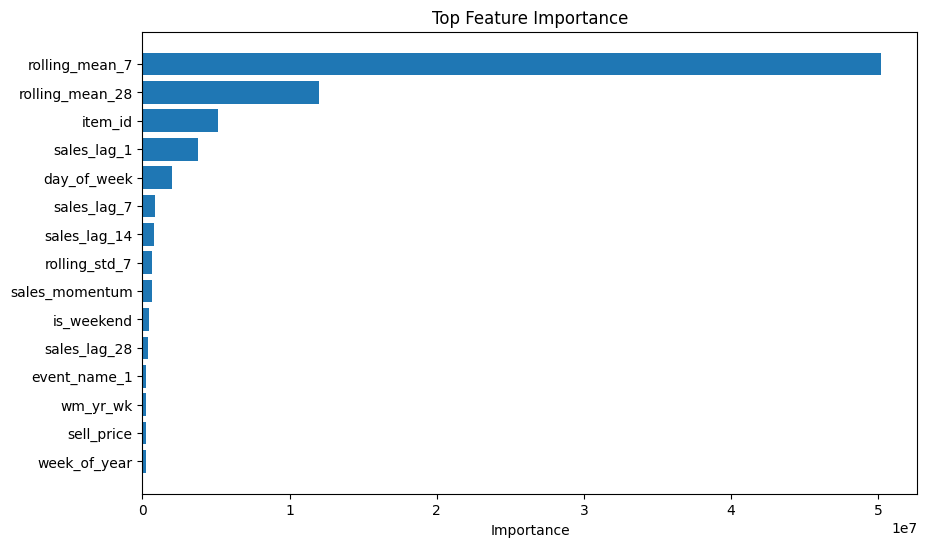

In [10]:
print("=== FEATURE IMPORTANCE ===")

import matplotlib.pyplot as plt

importance = model.feature_importance(importance_type='gain')
feature_names = X_train.columns

fi = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values(by='importance', ascending=False)

print(fi.head(15))

# Plot top features
plt.figure(figsize=(10,6))
plt.barh(fi['feature'][:15][::-1], fi['importance'][:15][::-1])
plt.title("Top Feature Importance")
plt.xlabel("Importance")
plt.show()

In [11]:
print("=== STEP 7: FUTURE DEMAND FORECAST (28 DAYS) ===")

forecast_horizon = 28

# Latest available data
latest_date = df_fe['date'].max()

# Use last known records per product
last_data = (
    df_fe.sort_values('date')
         .groupby(['store_id','item_id'])
         .tail(1)
         .copy()
)

future_predictions = []

for step in range(1, forecast_horizon + 1):

    future_date = latest_date + pd.Timedelta(days=step)

    temp = last_data.copy()
    temp['date'] = future_date

    # ---- Update time features ----
    temp['day_of_week'] = future_date.weekday()
    temp['week_of_year'] = future_date.isocalendar().week
    temp['month'] = future_date.month
    temp['quarter'] = (future_date.month - 1)//3 + 1
    temp['is_weekend'] = int(future_date.weekday() >= 5)

    # ---- Predict ----
    X_future = temp[X_train.columns]
    temp['predicted_sales'] = model.predict(X_future)

    future_predictions.append(temp[['store_id','item_id','date','predicted_sales']])

# Combine all steps
forecast_df = pd.concat(future_predictions).reset_index(drop=True)

print("Forecast shape:", forecast_df.shape)
print("\nSample forecast:")
print(forecast_df.head())

print("\nForecast complete.")

=== STEP 7: FUTURE DEMAND FORECAST (28 DAYS) ===


C:\Users\khush\AppData\Local\Temp\ipykernel_11156\1400945762.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['store_id','item_id'])


Forecast shape: (85372, 4)

Sample forecast:
  store_id          item_id       date  predicted_sales
0     CA_1      FOODS_3_817 2016-04-25         0.314441
1     CA_1      FOODS_2_330 2016-04-25         0.798013
2     CA_1  HOUSEHOLD_1_265 2016-04-25         0.750309
3     CA_1  HOUSEHOLD_1_473 2016-04-25         4.917318
4     CA_1      FOODS_3_096 2016-04-25         0.790358

Forecast complete.


In [12]:
print("=== STEP 8: INVENTORY OPTIMIZATION ===")

# Aggregate demand per product over horizon
inventory_plan = (
    forecast_df
    .groupby(['store_id','item_id'])['predicted_sales']
    .sum()
    .reset_index()
    .rename(columns={'predicted_sales':'forecast_28d'})
)

# ---- Safety stock calculation ----
# Using historical demand variability

demand_std = (
    df_fe.groupby(['store_id','item_id'])['sales']
         .std()
         .reset_index()
         .rename(columns={'sales':'demand_std'})
)

inventory_plan = inventory_plan.merge(
    demand_std,
    on=['store_id','item_id'],
    how='left'
)

# Fill missing std
inventory_plan['demand_std'] = inventory_plan['demand_std'].fillna(0)

# Service level factor (≈95%)
z_score = 1.65

inventory_plan['safety_stock'] = z_score * inventory_plan['demand_std']

# Final recommendation
inventory_plan['recommended_stock'] = (
    inventory_plan['forecast_28d'] +
    inventory_plan['safety_stock']
).round().astype(int)

print("Inventory plan shape:", inventory_plan.shape)

print("\nTop products needing stock:")
print(
    inventory_plan
    .sort_values('recommended_stock', ascending=False)
    .head(10)
)

print("\nInventory optimization complete.")

=== STEP 8: INVENTORY OPTIMIZATION ===
Inventory plan shape: (3049, 6)

Top products needing stock:
     store_id      item_id  forecast_28d  demand_std  safety_stock  \
702      CA_1  FOODS_3_090   2036.641018   34.054100     56.189265   
732      CA_1  FOODS_3_120   1456.682031   27.130205     44.764839   
1198     CA_1  FOODS_3_586   1181.415720   15.622597     25.777285   
864      CA_1  FOODS_3_252   1150.499281   16.262916     26.833812   
676      CA_1  FOODS_3_064    919.516084   10.780602     17.787993   
1199     CA_1  FOODS_3_587    725.772716   10.130830     16.715869   
907      CA_1  FOODS_3_295    714.800521   14.661383     24.191282   
1123     CA_1  FOODS_3_511    687.030399   12.364559     20.401522   
1113     CA_1  FOODS_3_501    653.603202   16.383805     27.033278   
894      CA_1  FOODS_3_282    655.294264   13.885078     22.910379   

      recommended_stock  
702                2093  
732                1501  
1198               1207  
864                1177  

C:\Users\khush\AppData\Local\Temp\ipykernel_11156\749696979.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['store_id','item_id'])['predicted_sales']
C:\Users\khush\AppData\Local\Temp\ipykernel_11156\749696979.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_fe.groupby(['store_id','item_id'])['sales']
